In [1]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [8]:
temp = xr.open_dataset('temp_new.nc') 
precip = xr.open_dataset('Precip_new.nc')
RH = xr.open_dataset('RH_new.nc')
WS = xr.open_dataset('wind_speed_new.nc')


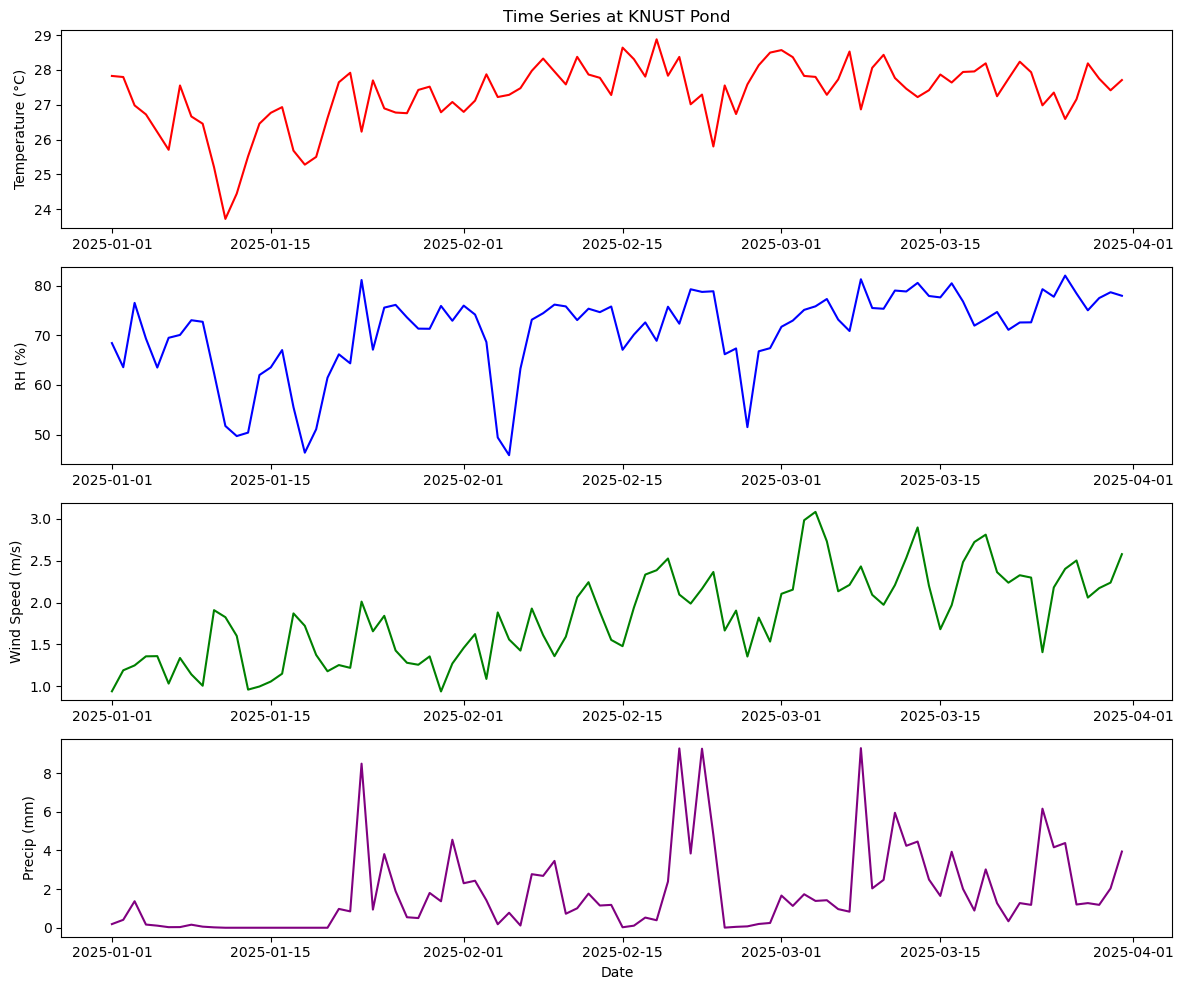

In [9]:
import xarray as xr
import matplotlib.pyplot as plt

# Load datasets
temp = xr.open_dataset('temp_new.nc') 
precip = xr.open_dataset('Precip_new.nc')
RH = xr.open_dataset('RH_new.nc')
WS = xr.open_dataset('wind_speed_new.nc')


# Target location: KNUST Pond
lat_pt = 6.6657
lon_pt = -1.57304

# Interpolate to exact point
temp_series = temp['T2M'].interp(lat=lat_pt, lon=lon_pt)
rh_series = RH['RH2M'].interp(lat=lat_pt, lon=lon_pt)
ws_series = WS['WS2M'].interp(lat=lat_pt, lon=lon_pt)
precip_series = precip['PRECTOTCORR'].interp(lat=lat_pt, lon=lon_pt)

# Create multipanel plot
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(12, 10), sharex=False)

# Plot each variable
axs[0].plot(temp_series['time'], temp_series, color='red')
axs[0].set_ylabel('Temperature (°C)')
axs[0].set_title('Time Series at KNUST Pond')

axs[1].plot(rh_series['time'], rh_series, color='blue')
axs[1].set_ylabel('RH (%)')

axs[2].plot(ws_series['time'], ws_series, color='green')
axs[2].set_ylabel('Wind Speed (m/s)')

axs[3].plot(precip_series['time'], precip_series, color='purple')
axs[3].set_ylabel('Precip (mm)')
axs[3].set_xlabel('Date')

plt.tight_layout()
plt.show()


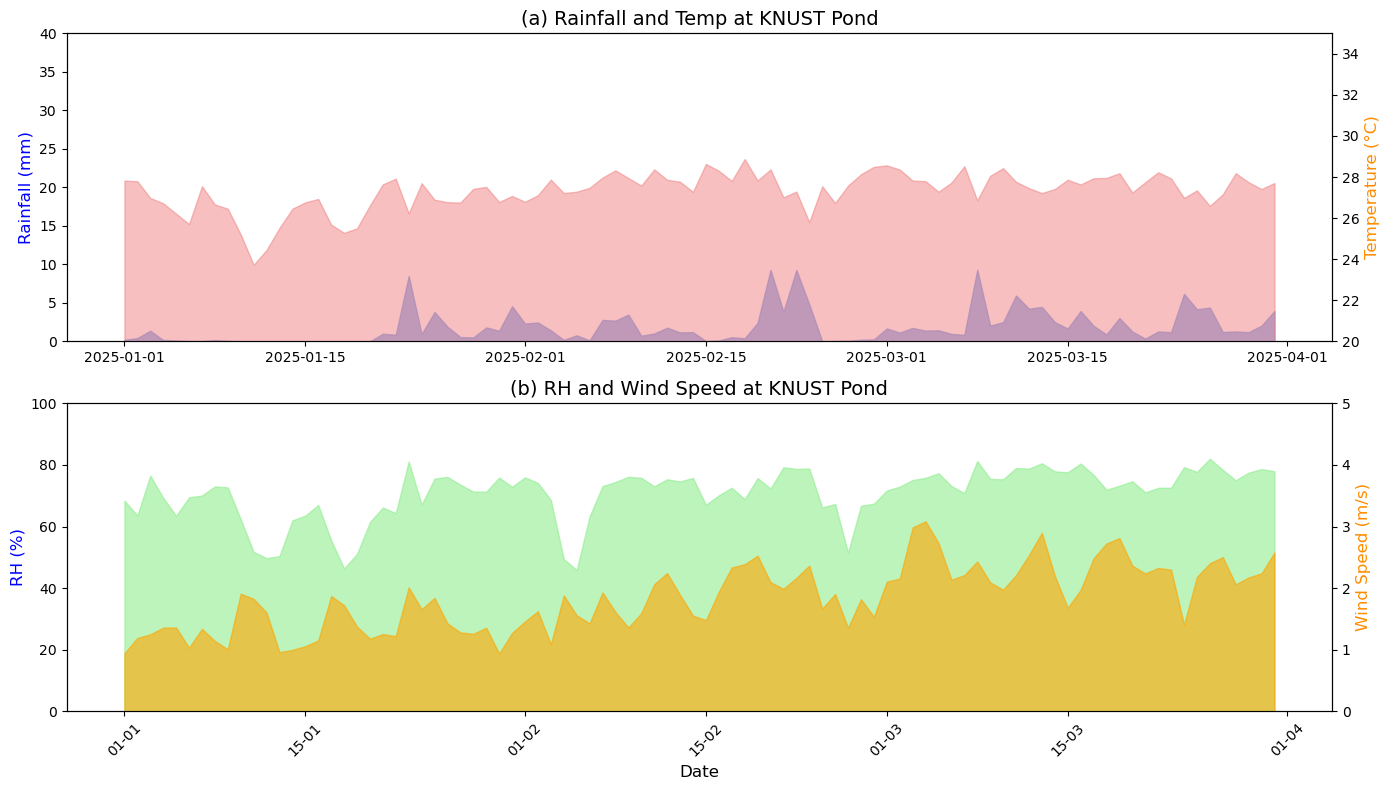

In [10]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load datasets
temp = xr.open_dataset('temp_new.nc') 
precip = xr.open_dataset('Precip_new.nc')
RH = xr.open_dataset('RH_new.nc')
WS = xr.open_dataset('wind_speed_new.nc')


# Coordinates for KNUST Pond
lat_pt = 6.6657
lon_pt = -1.57304

# Interpolate to location
temp_series = temp['T2M'].interp(lat=lat_pt, lon=lon_pt)
rh_series = RH['RH2M'].interp(lat=lat_pt, lon=lon_pt)
ws_series = WS['WS2M'].interp(lat=lat_pt, lon=lon_pt)
precip_series = precip['PRECTOTCORR'].interp(lat=lat_pt, lon=lon_pt)

# Create figure
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# ------------------ Panel A: Rainfall & Temp ------------------
ax1 = axs[0]
ax2 = ax1.twinx()

ax1.fill_between(precip_series['time'], precip_series, color='cornflowerblue', alpha=0.7, label='Rainfall')
ax2.fill_between(temp_series['time'], temp_series, color='lightcoral', alpha=0.5, label='Temperature')

ax1.set_ylabel('Rainfall (mm)', color='blue', fontsize=12)
ax2.set_ylabel('Temperature (°C)', color='darkorange', fontsize=12)

ax1.set_ylim(0, 40)
ax2.set_ylim(20, 35)

ax1.set_title('(a) Rainfall and Temp at KNUST Pond', fontsize=14)

# ------------------ Panel B: RH & Wind Speed ------------------
ax3 = axs[1]
ax4 = ax3.twinx()

ax3.fill_between(rh_series['time'], rh_series, color='lightgreen', alpha=0.6, label='RH')
ax4.fill_between(ws_series['time'], ws_series, color='orange', alpha=0.6, label='Wind Speed')

ax3.set_ylabel('RH (%)', color='blue', fontsize=12)
ax4.set_ylabel('Wind Speed (m/s)', color='darkorange', fontsize=12)

ax3.set_ylim(0, 100)
ax4.set_ylim(0, 5)

ax3.set_title('(b) RH and Wind Speed at KNUST Pond', fontsize=14)

# X-axis formatting
axs[1].set_xlabel('Date', fontsize=12)
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
axs[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


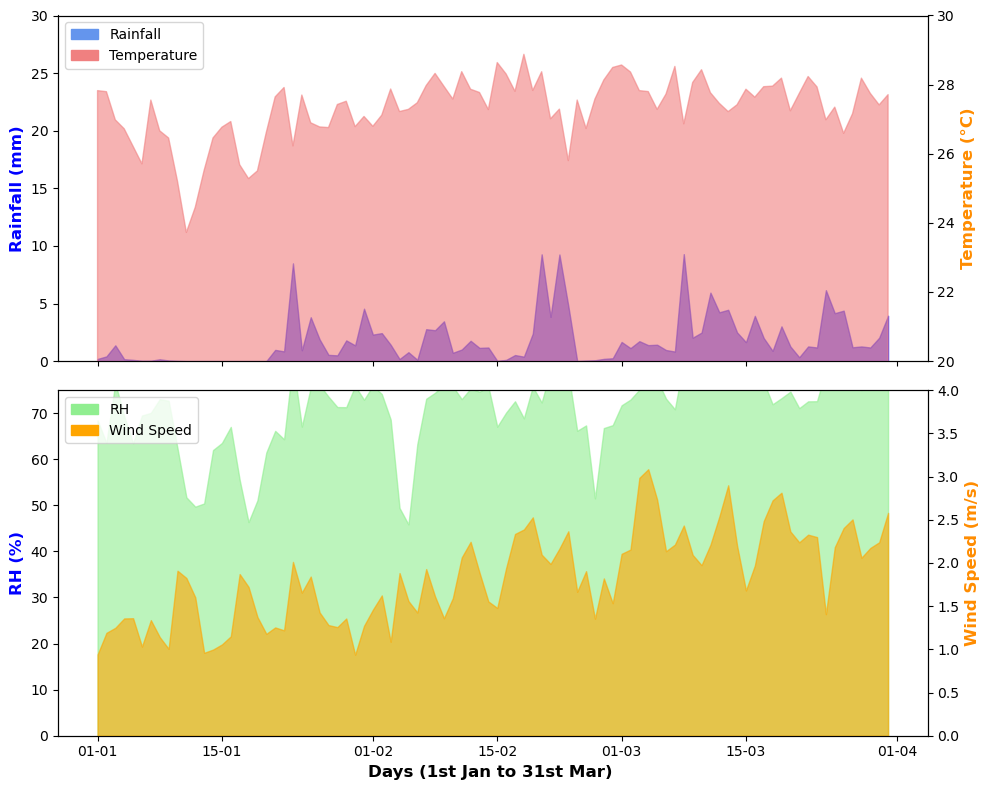

In [17]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# Load datasets
temp = xr.open_dataset('temp_new.nc') 
precip = xr.open_dataset('Precip_new.nc')
RH = xr.open_dataset('RH_new.nc')
WS = xr.open_dataset('wind_speed_new.nc')

# Coordinates for KNUST Pond
lat_pt = 6.6657
lon_pt = -1.57304

# Interpolate to location
temp_series = temp['T2M'].interp(lat=lat_pt, lon=lon_pt)
rh_series = RH['RH2M'].interp(lat=lat_pt, lon=lon_pt)
ws_series = WS['WS2M'].interp(lat=lat_pt, lon=lon_pt)
precip_series = precip['PRECTOTCORR'].interp(lat=lat_pt, lon=lon_pt)

# Create figure
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ------------------ Panel A: Rainfall & Temp ------------------
ax1 = axs[0]
ax2 = ax1.twinx()

ax1.fill_between(precip_series['time'], precip_series, color='blue', alpha=0.6)
ax2.fill_between(temp_series['time'], temp_series, color='lightcoral', alpha=0.6)

ax1.set_ylabel('Rainfall (mm)', color='blue', fontweight= 'bold', fontsize=12)
ax2.set_ylabel('Temperature (°C)', color='darkorange', fontweight= 'bold', fontsize=12)

ax1.set_ylim(0, 30)
ax2.set_ylim(20, 30)

# Legend for Panel A
rain_patch = mpatches.Patch(color='cornflowerblue', label='Rainfall')
temp_patch = mpatches.Patch(color='lightcoral', label='Temperature')
ax1.legend(handles=[rain_patch, temp_patch], loc='upper left')

# ------------------ Panel B: RH & Wind Speed ------------------
ax3 = axs[1]
ax4 = ax3.twinx()

ax3.fill_between(rh_series['time'], rh_series, color='lightgreen', alpha=0.6)
ax4.fill_between(ws_series['time'], ws_series, color='orange', alpha=0.6)

ax3.set_ylabel('RH (%)', color='blue', fontweight= 'bold', fontsize=12)
ax4.set_ylabel('Wind Speed (m/s)', color='darkorange', fontweight= 'bold', fontsize=12)

ax3.set_ylim(0, 75)
ax4.set_ylim(0, 4)

# Legend for Panel B
rh_patch = mpatches.Patch(color='lightgreen', label='RH')
ws_patch = mpatches.Patch(color='orange', label='Wind Speed')
ax3.legend(handles=[rh_patch, ws_patch], loc='upper left')

# X-axis formatting
axs[1].set_xlabel('Days (1st Jan to 31st Mar) ', fontweight= 'bold', fontsize=12)
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
axs[1].tick_params(axis='x')

plt.tight_layout()
plt.show()


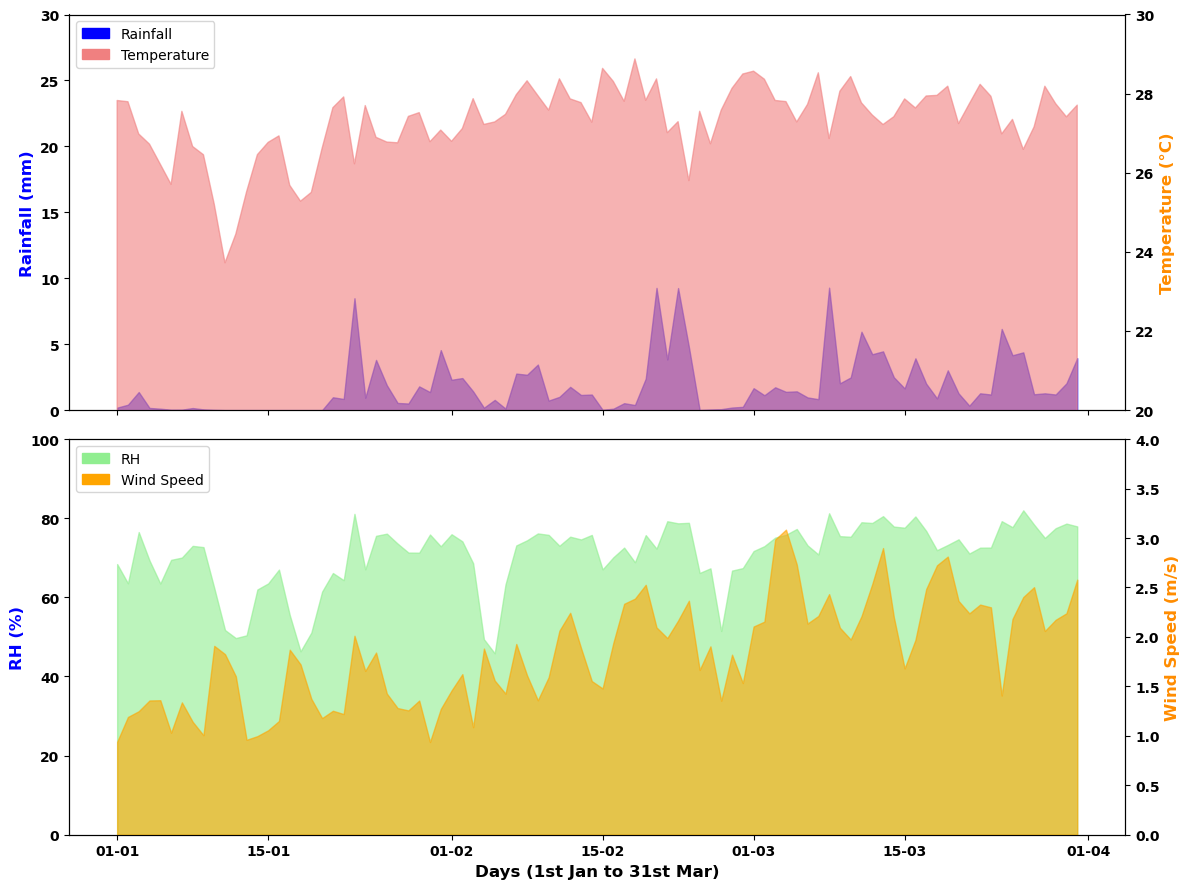

In [18]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# Load datasets
temp = xr.open_dataset('temp_new.nc') 
precip = xr.open_dataset('Precip_new.nc')
RH = xr.open_dataset('RH_new.nc')
WS = xr.open_dataset('wind_speed_new.nc')


# Coordinates for KNUST Pond
lat_pt = 6.6657
lon_pt = -1.57304

# Interpolate to location
temp_series = temp['T2M'].interp(lat=lat_pt, lon=lon_pt)
rh_series = RH['RH2M'].interp(lat=lat_pt, lon=lon_pt)
ws_series = WS['WS2M'].interp(lat=lat_pt, lon=lon_pt)
precip_series = precip['PRECTOTCORR'].interp(lat=lat_pt, lon=lon_pt)

# Create figure
fig, axs = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# ------------------ Panel A: Rainfall & Temp ------------------
ax1 = axs[0]
ax2 = ax1.twinx()

ax1.fill_between(precip_series['time'], precip_series, color='blue', alpha=0.6)
ax2.fill_between(temp_series['time'], temp_series, color='lightcoral', alpha=0.6)

ax1.set_ylabel('Rainfall (mm)', color='blue', fontweight='bold', fontsize=12)
ax2.set_ylabel('Temperature (°C)', color='darkorange', fontweight='bold', fontsize=12)

ax1.set_ylim(0, 30)
ax2.set_ylim(20, 30)

# Legend for Panel A
rain_patch = mpatches.Patch(color='blue', label='Rainfall')
temp_patch = mpatches.Patch(color='lightcoral', label='Temperature')
ax1.legend(handles=[rain_patch, temp_patch], loc='upper left')

# ------------------ Panel B: RH & Wind Speed ------------------
ax3 = axs[1]
ax4 = ax3.twinx()

ax3.fill_between(rh_series['time'], rh_series, color='lightgreen', alpha=0.6)
ax4.fill_between(ws_series['time'], ws_series, color='orange', alpha=0.6)

ax3.set_ylabel('RH (%)', color='blue', fontweight='bold', fontsize=12)
ax4.set_ylabel('Wind Speed (m/s)', color='darkorange', fontweight='bold', fontsize=12)

ax3.set_ylim(0, 100)
ax4.set_ylim(0, 4)

# Legend for Panel B
rh_patch = mpatches.Patch(color='lightgreen', label='RH')
ws_patch = mpatches.Patch(color='orange', label='Wind Speed')
ax3.legend(handles=[rh_patch, ws_patch], loc='upper left')

# X-axis formatting
axs[1].set_xlabel('Days (1st Jan to 31st Mar)', fontweight='bold', fontsize=12)
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
axs[1].tick_params(axis='x')

# -------- BOLD TICK LABELS FOR ALL AXES --------
for ax in [ax1, ax2, ax3, ax4, axs[1]]:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(10)  # Adjust as needed

plt.tight_layout()
fig.savefig('panel.png',bbox_inches='tight',dpi=500)
plt.show()


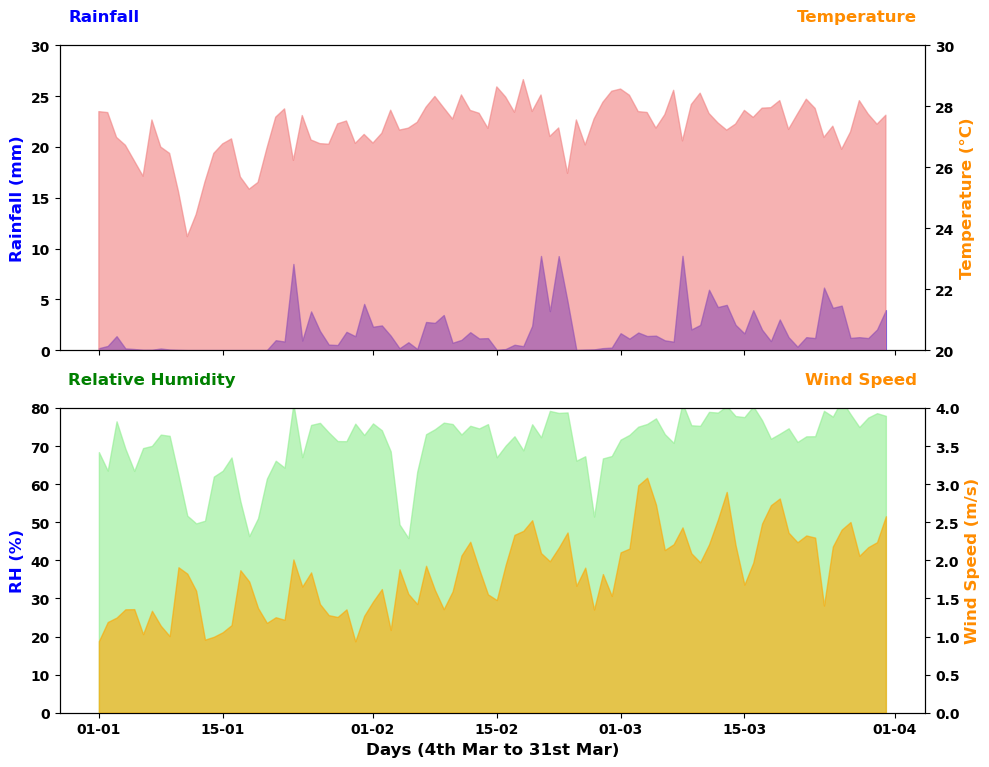

In [13]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# Load datasets
temp = xr.open_dataset('temp_new.nc') 
precip = xr.open_dataset('Precip_new.nc')
RH = xr.open_dataset('RH_new.nc')
WS = xr.open_dataset('wind_speed_new.nc')


# Coordinates for KNUST Pond
lat_pt = 6.6657
lon_pt = -1.57304

# Interpolate to location
temp_series = temp['T2M'].interp(lat=lat_pt, lon=lon_pt)
rh_series = RH['RH2M'].interp(lat=lat_pt, lon=lon_pt)
ws_series = WS['WS2M'].interp(lat=lat_pt, lon=lon_pt)
precip_series = precip['PRECTOTCORR'].interp(lat=lat_pt, lon=lon_pt)

# Create figure
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ------------------ Panel A: Rainfall & Temp ------------------
ax1 = axs[0]
ax2 = ax1.twinx()

ax1.fill_between(precip_series['time'], precip_series, color='blue', alpha=0.6)
ax2.fill_between(temp_series['time'], temp_series, color='lightcoral', alpha=0.6)

ax1.set_ylabel('Rainfall (mm)', color='blue', fontweight='bold', fontsize=12)
ax2.set_ylabel('Temperature (°C)', color='darkorange', fontweight='bold', fontsize=12)

ax1.set_ylim(0, 30)
ax2.set_ylim(20, 30)

# "Legend" above plot - Panel A
ax1.text(0.01, 1.08, 'Rainfall', transform=ax1.transAxes, fontsize=12, fontweight='bold', color='blue', ha='left')
ax1.text(0.99, 1.08, 'Temperature', transform=ax1.transAxes, fontsize=12, fontweight='bold', color='darkorange', ha='right')

# ------------------ Panel B: RH & Wind Speed ------------------
ax3 = axs[1]
ax4 = ax3.twinx()

ax3.fill_between(rh_series['time'], rh_series, color='lightgreen', alpha=0.6)
ax4.fill_between(ws_series['time'], ws_series, color='orange', alpha=0.6)

ax3.set_ylabel('RH (%)', color='blue', fontweight='bold', fontsize=12)
ax4.set_ylabel('Wind Speed (m/s)', color='darkorange', fontweight='bold', fontsize=12)

ax3.set_ylim(0, 80)
ax4.set_ylim(0, 4)

# "Legend" above plot - Panel B
ax3.text(0.01, 1.08, 'Relative Humidity', transform=ax3.transAxes, fontsize=12, fontweight='bold', color='green', ha='left')
ax3.text(0.99, 1.08, 'Wind Speed', transform=ax3.transAxes, fontsize=12, fontweight='bold', color='darkorange', ha='right')

# X-axis formatting
axs[1].set_xlabel('Days (4th Mar to 31st Mar)', fontweight='bold', fontsize=12)
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
axs[1].tick_params(axis='x')

# -------- BOLD TICK LABELS FOR ALL AXES --------
for ax in [ax1, ax2, ax3, ax4, axs[1]]:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(10)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # add space for text above plots
fig.savefig('panel.png', bbox_inches='tight', dpi=500)
plt.show()


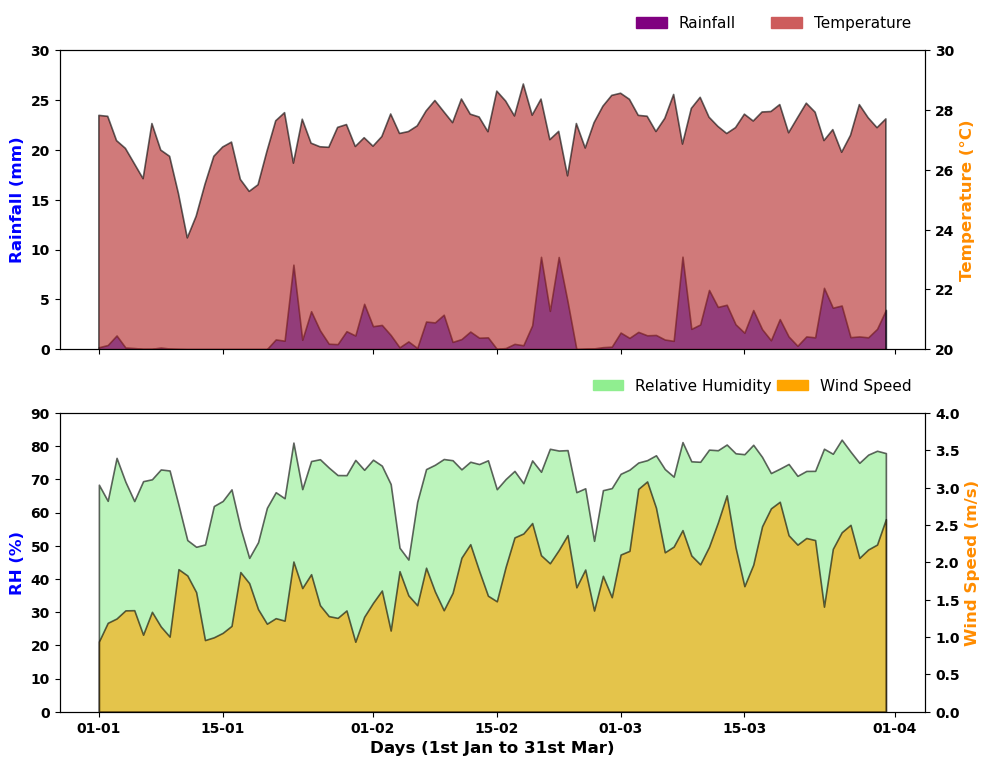

In [42]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# Load datasets
temp = xr.open_dataset('temp_new.nc') 
precip = xr.open_dataset('Precip_new.nc')
RH = xr.open_dataset('RH_new.nc')
WS = xr.open_dataset('wind_speed_new.nc')


# Coordinates for KNUST Pond
lat_pt = 6.6657
lon_pt = -1.57304

# Interpolate to location
temp_series = temp['T2M'].interp(lat=lat_pt, lon=lon_pt)
rh_series = RH['RH2M'].interp(lat=lat_pt, lon=lon_pt)
ws_series = WS['WS2M'].interp(lat=lat_pt, lon=lon_pt)
precip_series = precip['PRECTOTCORR'].interp(lat=lat_pt, lon=lon_pt)

# Create figure
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ------------------ Panel A: Rainfall & Temp ------------------
ax1 = axs[0]
ax2 = ax1.twinx()

ax1.fill_between(precip_series['time'], precip_series, color='blue', alpha=0.6,
                 edgecolor='black', linewidth=1.2)

ax2.fill_between(temp_series['time'], temp_series, color='firebrick', alpha=0.6,
                 edgecolor='black', linewidth=1.2)

ax1.set_ylabel('Rainfall (mm)', color='blue', fontweight='bold', fontsize=12)
ax2.set_ylabel('Temperature (°C)', color='darkorange', fontweight='bold', fontsize=12)

ax1.set_ylim(0, 30)
ax2.set_ylim(20, 30)

# Legends above for Panel A
rain_patch = mpatches.Patch(color='purple', label='Rainfall')
temp_patch = mpatches.Patch(color='indianred', label='Temperature')

ax1.legend(handles=[rain_patch], loc='lower left', bbox_to_anchor=(0.65, 1.02), fontsize=11, frameon=False)
ax2.legend(handles=[temp_patch], loc='lower right', bbox_to_anchor=(1, 1.02), fontsize=11, frameon=False)

# ------------------ Panel B: RH & Wind Speed ------------------
ax3 = axs[1]
ax4 = ax3.twinx()

ax3.fill_between(rh_series['time'], rh_series, color='lightgreen', alpha=0.6,
                 edgecolor='black',linewidth=1.2)

ax4.fill_between(ws_series['time'], ws_series, color='orange', alpha=0.6,
                 edgecolor='black', linewidth=1.2)

ax3.set_ylabel('RH (%)', color='blue', fontweight='bold', fontsize=12)
ax4.set_ylabel('Wind Speed (m/s)', color='darkorange', fontweight='bold', fontsize=12)

ax3.set_ylim(0, 90)
ax4.set_ylim(0, 4)

# Legends above for Panel B
rh_patch = mpatches.Patch(color='lightgreen', label='Relative Humidity')
ws_patch = mpatches.Patch(color='orange', label='Wind Speed')

ax3.legend(handles=[rh_patch], loc='lower left', bbox_to_anchor=(0.60, 1.02), fontsize=11, frameon=False)
ax4.legend(handles=[ws_patch], loc='lower right', bbox_to_anchor=(1, 1.02), fontsize=11, frameon=False)

# X-axis formatting
axs[1].set_xlabel('Days (1st Jan to 31st Mar)', fontweight='bold', fontsize=12)
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
axs[1].tick_params(axis='x')

# -------- BOLD TICK LABELS FOR ALL AXES --------
for ax in [ax1, ax2, ax3, ax4, axs[1]]:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(10)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # space for top legends
fig.savefig('panel.png', bbox_inches='tight', dpi=500)
plt.show()


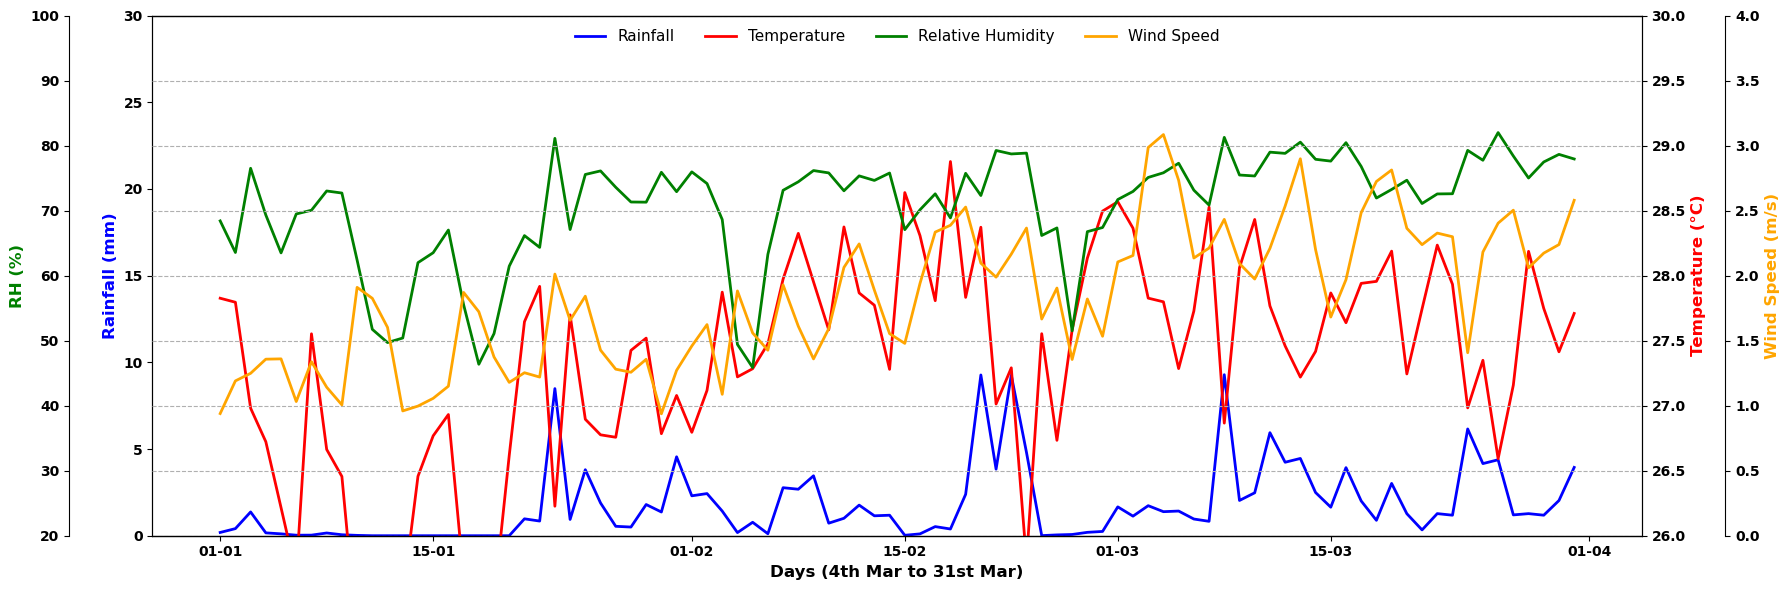

In [43]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# Load datasets
temp = xr.open_dataset('temp_new.nc') 
precip = xr.open_dataset('Precip_new.nc')
RH = xr.open_dataset('RH_new.nc')
WS = xr.open_dataset('wind_speed_new.nc')


# Coordinates for KNUST Pond
lat_pt = 6.6657
lon_pt = -1.57304

# Interpolate to location
temp_series = temp['T2M'].interp(lat=lat_pt, lon=lon_pt)
rh_series = RH['RH2M'].interp(lat=lat_pt, lon=lon_pt)
ws_series = WS['WS2M'].interp(lat=lat_pt, lon=lon_pt)
precip_series = precip['PRECTOTCORR'].interp(lat=lat_pt, lon=lon_pt)

# Create figure and base axis
fig, ax1 = plt.subplots(figsize=(18, 6))

# Create other y-axes
ax2 = ax1.twinx()  # Temperature
ax3 = ax1.twinx()  # RH
ax4 = ax1.twinx()  # Wind Speed

# Offset RH axis (ax3) to the left
ax3.spines["left"].set_position(("outward", 60))
ax3.yaxis.set_label_position("left")
ax3.yaxis.set_ticks_position("left")

# Offset Wind Speed axis (ax4) to the right
ax4.spines["right"].set_position(("outward", 60))
ax4.yaxis.set_label_position("right")
ax4.yaxis.set_ticks_position("right")

# Hide duplicate spines
ax3.spines["right"].set_visible(False)
ax4.spines["left"].set_visible(False)

# Plot lines
ln1, = ax1.plot(precip_series['time'], precip_series, color='blue', linewidth=2, label='Rainfall')
ln2, = ax2.plot(temp_series['time'], temp_series, color='red', linewidth=2, label='Temperature')
ln3, = ax3.plot(rh_series['time'], rh_series, color='green', linewidth=2, label='Relative Humidity')
ln4, = ax4.plot(ws_series['time'], ws_series, color='orange', linewidth=2, label='Wind Speed')

# Set y-labels
ax1.set_ylabel('Rainfall (mm)', color='blue', fontsize=12, fontweight='bold')
ax2.set_ylabel('Temperature (°C)', color='red', fontsize=12, fontweight='bold')
ax3.set_ylabel('RH (%)', color='green', fontsize=12, fontweight='bold')
ax4.set_ylabel('Wind Speed (m/s)', color='orange', fontsize=12, fontweight='bold')

# Set y-axis limits (optional, tweak based on your data)
ax1.set_ylim(0, 30)
ax2.set_ylim(26, 30)
ax3.set_ylim(20, 100)
ax4.set_ylim(0, 4)

# X-axis formatting
ax1.set_xlabel('Days (4th Mar to 31st Mar)', fontsize=12, fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

# Bold tick labels
for ax in [ax1, ax2, ax3, ax4]:
    for label in ax.get_yticklabels() + ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(10)

# Create a unified legend
lines = [ln1, ln2, ln3, ln4]
labels = [l.get_label() for l in lines]
plt.legend(lines, labels, loc='upper center', ncol=4, frameon=False, fontsize=11)
plt.grid(True, axis='both', linestyle='--')

plt.tight_layout()
fig.savefig("quad_axis_plot_three.png", dpi=500, bbox_inches='tight')
plt.show()


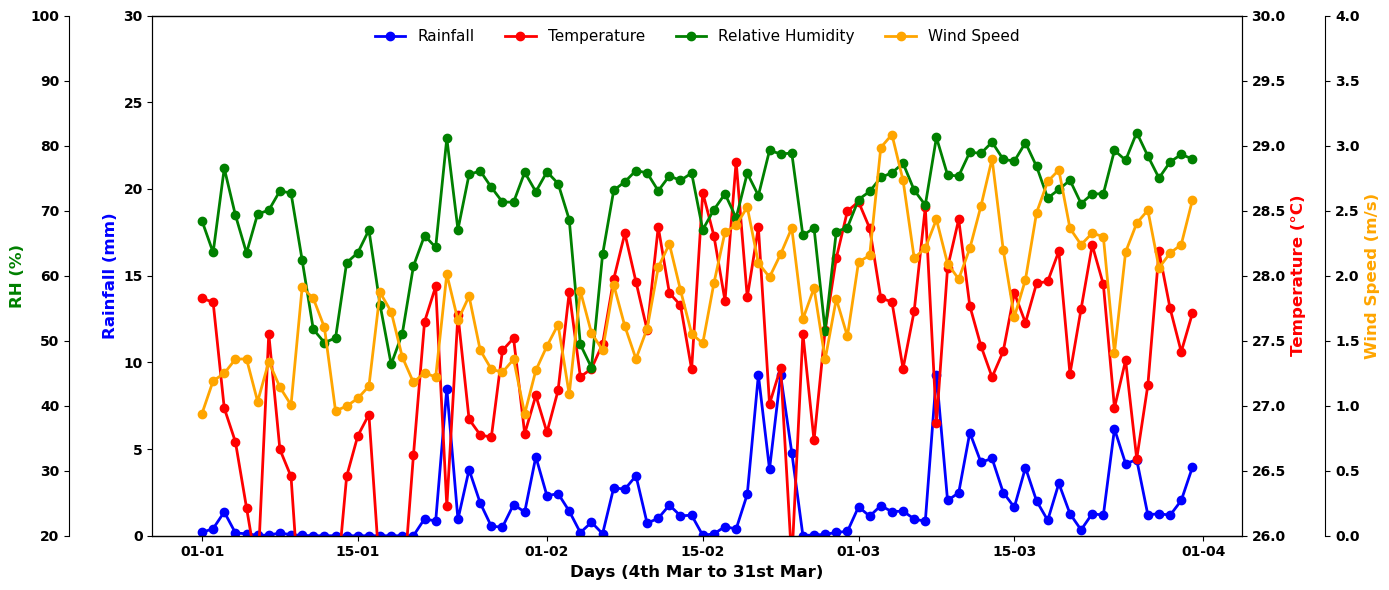

In [16]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# Load datasets
temp = xr.open_dataset('temp_new.nc') 
precip = xr.open_dataset('Precip_new.nc')
RH = xr.open_dataset('RH_new.nc')
WS = xr.open_dataset('wind_speed_new.nc')


# Coordinates for KNUST Pond
lat_pt = 6.6657
lon_pt = -1.57304

# Interpolate to location
temp_series = temp['T2M'].interp(lat=lat_pt, lon=lon_pt)
rh_series = RH['RH2M'].interp(lat=lat_pt, lon=lon_pt)
ws_series = WS['WS2M'].interp(lat=lat_pt, lon=lon_pt)
precip_series = precip['PRECTOTCORR'].interp(lat=lat_pt, lon=lon_pt)

# Create figure and base axis
fig, ax1 = plt.subplots(figsize=(14, 6))

# Create other y-axes
ax2 = ax1.twinx()  # Temperature
ax3 = ax1.twinx()  # RH
ax4 = ax1.twinx()  # Wind Speed

# Offset RH axis (ax3) to the left
ax3.spines["left"].set_position(("outward", 60))
ax3.yaxis.set_label_position("left")
ax3.yaxis.set_ticks_position("left")

# Offset Wind Speed axis (ax4) to the right
ax4.spines["right"].set_position(("outward", 60))
ax4.yaxis.set_label_position("right")
ax4.yaxis.set_ticks_position("right")

# Hide duplicate spines
ax3.spines["right"].set_visible(False)
ax4.spines["left"].set_visible(False)

# Plot lines
ln1, = ax1.plot(precip_series['time'], precip_series, color='blue', linewidth=2, label='Rainfall', marker='o')
ln2, = ax2.plot(temp_series['time'], temp_series, color='red', linewidth=2, label='Temperature', marker='o')
ln3, = ax3.plot(rh_series['time'], rh_series, color='green', linewidth=2, label='Relative Humidity', marker='o')
ln4, = ax4.plot(ws_series['time'], ws_series, color='orange', linewidth=2, label='Wind Speed', marker='o')

# Set y-labels
ax1.set_ylabel('Rainfall (mm)', color='blue', fontsize=12, fontweight='bold')
ax2.set_ylabel('Temperature (°C)', color='red', fontsize=12, fontweight='bold')
ax3.set_ylabel('RH (%)', color='green', fontsize=12, fontweight='bold')
ax4.set_ylabel('Wind Speed (m/s)', color='orange', fontsize=12, fontweight='bold')

# Set y-axis limits (optional, tweak based on your data)
ax1.set_ylim(0, 30)
ax2.set_ylim(26, 30)
ax3.set_ylim(20, 100)
ax4.set_ylim(0, 4)

# X-axis formatting
ax1.set_xlabel('Days (4th Mar to 31st Mar)', fontsize=12, fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

# Bold tick labels
for ax in [ax1, ax2, ax3, ax4]:
    for label in ax.get_yticklabels() + ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(10)

# Create a unified legend
lines = [ln1, ln2, ln3, ln4]
labels = [l.get_label() for l in lines]
plt.legend(lines, labels, loc='upper center', ncol=4, frameon=False, fontsize=11)

plt.tight_layout()
fig.savefig("quad_axis_plot_two.png", dpi=500, bbox_inches='tight')
plt.show()


In [37]:
gases =  pd.read_excel('Field_Data_FINAL.xlsx')
gases

,DATE,Time,CH4,CO2,O2,NH3,CO,H2S,TEMP
0,2025-03-03,06:00:00,0.0,0.1,20.5,1,0,2,NaN
1,2025-03-03,12:00:00,0.0,0.0,20.9,11,0,0,33.1
2,2025-03-03,18:00:00,0.0,0.1,21.4,2,1,2,32.8
3,2025-03-04,06:00:00,0.0,0.0,20.7,2,8,1,28.7
4,2025-03-04,12:00:00,0.0,0.0,19.6,5,13,2,31.5
...,...,...,...,...,...,...,...,...,...
109,2025-03-31,00:00:00,0.0,0.0,20.8,4,0,1,30.0
110,2025-03-31,06:00:00,0.0,0.1,20.6,4,0,1,28.3
111,2025-03-31,12:00:00,0.0,0.1,20.1,0,0,1,32.1
112,2025-03-31,18:00:00,0.0,0.1,20.2,4,3,1,31.6
